# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [2]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

state vector dim = 4
n_actions = 2


/home/users/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


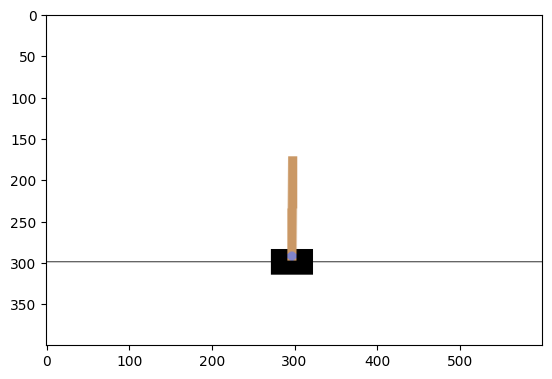

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [4]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [5]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward

In [6]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)

states: [[-0.0165822   0.02729358 -0.00902851 -0.04109913]
 [-0.01603633 -0.16769774 -0.00985049  0.2487216 ]
 [-0.01939028  0.02756348 -0.00487606 -0.04705204]
 [-0.01883901 -0.16748822 -0.0058171   0.24408847]
 [-0.02218878  0.02771634 -0.00093533 -0.05042362]]
actions: [0, 1, 0, 1, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [7]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states = [s for i, session in enumerate(states_batch) if rewards_batch[i] >= reward_threshold for s in session]
    elite_actions = [a for i, session in enumerate(actions_batch) if rewards_batch[i] >= reward_threshold for a in session]

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [8]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()

mean reward = 222.710, threshold=246.300


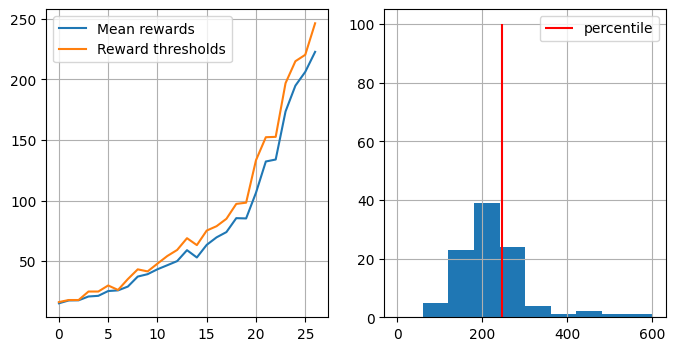

You Win! You may stop training now via KeyboardInterrupt.


KeyboardInterrupt: 

In [9]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(
        states_batch,
        actions_batch,
        rewards_batch,
        percentile
    )

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")

# Results

In [10]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]

/home/users/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/home/users/.venv/lib/python3.12/site-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /home/users/leras/RL/week01/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-0.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-0.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-1.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-1.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-1.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-2.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-2.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-2.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-3.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-3.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-3.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-4.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-4.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-4.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-5.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-5.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-5.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-6.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-6.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-6.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-7.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-7.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-7.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-8.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-8.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-8.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-9.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-9.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-9.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-10.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-10.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-10.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-11.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-11.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-11.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-12.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-12.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-12.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-13.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-13.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-13.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-14.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-14.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-14.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-15.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-15.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-15.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-16.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-16.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-16.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-17.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-17.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-17.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-18.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-18.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-18.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-19.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-19.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-19.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-20.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-20.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-20.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-21.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-21.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-21.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-22.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-22.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-22.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-23.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-23.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-23.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-24.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-24.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-24.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-25.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-25.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-25.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-26.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-26.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-26.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-27.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-27.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-27.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-28.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-28.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-28.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-29.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-29.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-29.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-30.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-30.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-30.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-31.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-31.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-31.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-32.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-32.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-32.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-33.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-33.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-33.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-34.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-34.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-34.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-35.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-35.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-35.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-36.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-36.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-36.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-37.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-37.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-37.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-38.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-38.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-38.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-39.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-39.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-39.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-40.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-40.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-40.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-41.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-41.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-41.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-42.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-42.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-42.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-43.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-43.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-43.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-44.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-44.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-44.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-45.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-45.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-45.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-46.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-46.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-46.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-47.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-47.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-47.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-48.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-48.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-48.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-49.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-49.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-49.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-50.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-50.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-50.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-51.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-51.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-51.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-52.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-52.mp4



MoviePy - Done !


MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-52.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-53.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-53.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-53.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-54.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-54.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-54.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-55.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-55.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-55.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-56.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-56.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-56.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-57.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-57.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-57.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-58.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-58.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-58.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-59.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-59.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-59.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-60.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-60.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-60.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-61.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-61.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-61.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-62.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-62.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-62.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-63.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-63.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-63.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-64.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-64.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-64.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-65.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-65.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-65.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-66.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-66.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-66.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-67.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-67.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-67.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-68.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-68.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-68.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-69.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-69.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-69.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-70.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-70.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-70.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-71.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-71.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-71.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-72.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-72.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-72.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-73.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-73.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-73.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-74.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-74.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-74.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-75.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-75.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-75.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-76.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-76.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-76.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-77.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-77.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-77.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-78.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-78.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-78.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-79.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-79.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-79.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-80.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-80.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-80.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-81.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-81.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-81.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-82.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-82.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-82.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-83.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-83.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-83.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-84.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-84.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-84.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-85.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-85.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-85.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-86.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-86.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-86.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-87.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-87.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-87.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-88.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-88.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-88.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-89.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-89.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-89.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-90.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-90.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-90.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-91.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-91.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-91.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-92.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-92.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-92.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-93.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-93.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-93.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-94.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-94.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-94.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-95.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-95.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-95.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-96.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-96.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-96.mp4
MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-97.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-97.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-97.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-98.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-98.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-98.mp4


MoviePy - Building video /home/users/leras/RL/week01/videos/rl-video-episode-99.mp4.
MoviePy - Writing video /home/users/leras/RL/week01/videos/rl-video-episode-99.mp4



MoviePy - Done !
MoviePy - video ready /home/users/leras/RL/week01/videos/rl-video-episode-99.mp4


In [11]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)

# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


# Homework Part I

### Задание 1.1. Исследование влияния гиперпараметров

Исследуем, как значения `percentile` и `n_sessions` влияют на скорость и качество обучения.
Для этого возьмём код из [`./crossentropy_method.ipynb`](./crossentropy_method.ipynb) и запустим подбор гиперпараметров.

(314, {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)})


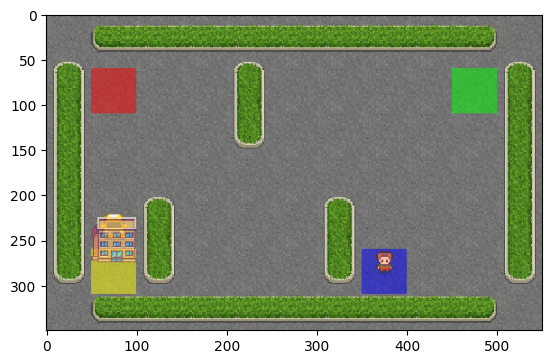

In [12]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3", render_mode="rgb_array")
print(env.reset(seed=0))
plt.imshow(env.render())

In [13]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"n_states={n_states}, n_actions={n_actions}")

n_states=500, n_actions=6


In [14]:
def initialize_policy(n_states, n_actions):
    policy = np.ones((n_states, n_actions)) / n_actions

    return policy

policy = initialize_policy(n_states, n_actions)

In [15]:
def generate_session(env, policy, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        a = np.random.choice(n_actions, p=policy[s])

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

In [16]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = [s for i, session in enumerate(states_batch) if rewards_batch[i] >= reward_threshold for s in session]
    elite_actions = [a for i, session in enumerate(actions_batch) if rewards_batch[i] >= reward_threshold for a in session]

    return elite_states, elite_actions

In [17]:
def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    for state, action in zip(elite_states, elite_actions):
        new_policy[state, action] += 1
        
    row_sums = new_policy.sum(axis=1, keepdims=True)
    
    safe_row_sums = np.where(row_sums == 0, 1, row_sums)
    new_policy = new_policy / safe_row_sums
    new_policy[row_sums.flatten() == 0] = 1.0 / n_actions

    return new_policy

In [18]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

In [19]:
def train_cem(n_sessions=250, percentile=50, learning_rate=0.5, n_iterations=100, t_max=10000):
    policy = initialize_policy(n_states, n_actions)
    log = []
    for i in range(n_iterations):
        sessions = [generate_session(env, policy, t_max=t_max) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
        new_policy = get_new_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        mean_reward = np.mean(rewards_batch)
        threshold = np.percentile(rewards_batch, percentile)
        log.append([mean_reward, threshold])
    return log

percentiles_to_test = [20, 30, 50, 70, 90]
nsessions_to_test = [100, 250, 500]

results_percentile = {}
for p in percentiles_to_test:
    print(f"Training with percentile={p}")
    results_percentile[p] = train_cem(percentile=p)
print("\n")

results_nsessions = {}
for ns in nsessions_to_test:
    print(f"Training with n_sessions={ns}")
    results_nsessions[ns] = train_cem(n_sessions=ns)

Training with percentile=20
Training with percentile=30
Training with percentile=50
Training with percentile=70
Training with percentile=90


Training with n_sessions=100
Training with n_sessions=250
Training with n_sessions=500


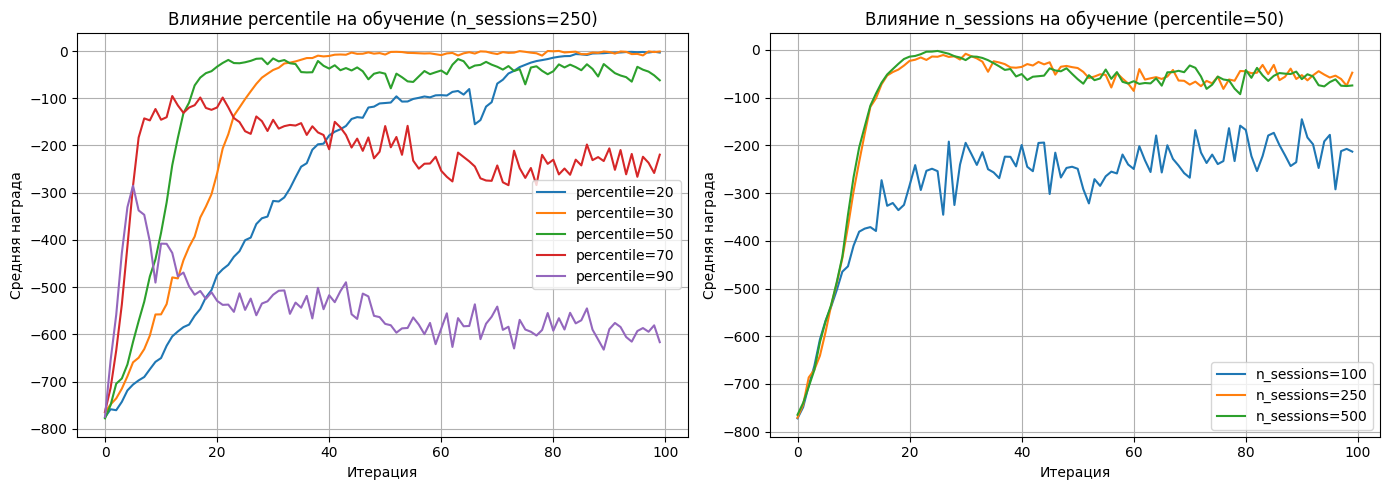

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for p in percentiles_to_test:
    mean_rewards = [x[0] for x in results_percentile[p]]
    ax.plot(mean_rewards, label=f"percentile={p}")
ax.set_xlabel("Итерация")
ax.set_ylabel("Средняя награда")
ax.set_title("Влияние percentile на обучение (n_sessions=250)")
ax.legend()
ax.grid(True)

ax = axes[1]
for ns in nsessions_to_test:
    mean_rewards = [x[0] for x in results_nsessions[ns]]
    ax.plot(mean_rewards, label=f"n_sessions={ns}")
ax.set_xlabel("Итерация")
ax.set_ylabel("Средняя награда")
ax.set_title("Влияние n_sessions на обучение (percentile=50)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

Параметр `percentile` существенно влияет на качество и стабильность обучения агента. При низких значениях (20–30) обучение происходит более плавно и устойчиво, поскольку в множество элитных сессий попадает больше траекторий, однако слишком маленький `percentile` замедляет улучшение политики, так как учитываются и неудачные эпизоды. Значение 30 показало наиболее удачный баланс между скоростью и стабильностью обучения. При `percentile`=50 агент очень быстро достигает высоких результатов, но затем появляются колебания качества. Высокие значения (70 и особенно 90) приводят к ухудшению обучения: элитных сессий становится слишком мало, политика обновляется по шумным данным, из-за чего агент застревает в плохих стратегиях и средняя награда остаётся низкой.

Параметр `n_sessions` определяет количество эпизодов, используемых на каждой итерации обучения, и влияет на стабильность оценки политики. При `n_sessions`=100 обучение получается очень шумным: средняя награда сильно колеблется, а агент не может стабильно улучшать поведение из-за недостатка данных. Увеличение числа сессий до 250 даёт наилучший результат — обучение становится более стабильным и быстро приводит к высоким значениям награды. При дальнейшем увеличении до 500 обучение остаётся устойчивым, однако улучшение происходит медленнее и итоговое качество немного хуже, поскольку обновления политики становятся слишком сглаженными и агент теряет часть исследовательского поведения.

### Задание 1.2. Настройка алгоритма для положительного среднего балла

Проблема стандартных настроек: алгоритм быстро достигает хорошего результата, а затем деградирует из-за случайности начальных состояний. Уменьшим percentile (чтобы не терять редкие стартовые состояния) и увеличим число сессий.

mean reward = 1.283, threshold=3.000


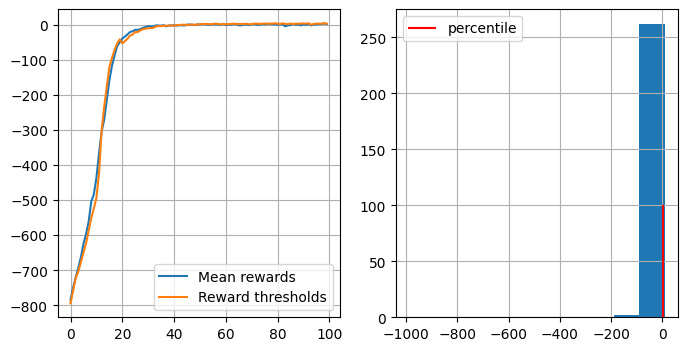

In [21]:
policy = initialize_policy(n_states, n_actions)

n_sessions = 250
percentile = 50
learning_rate = 0.5

log = []

for i in range(100):
    if i == 20:
        n_sessions = 300
        percentile = 25

    %time sessions = [generate_session(env, policy, t_max=10000) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    new_policy = get_new_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    show_progress(rewards_batch, log, percentile)

Получилось достичь пожительного среднего балла: `mean reward = 1.283`.

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [22]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # # The above code is equivalent to the following:
    # probs = np.empty((len(vs), len(xs), 3))
    # for i, v in enumerate(vs[::-1]):
    #     for j, x in enumerate(xs):
    #         probs[i, j, :] = agent.predict_proba([[x, v]])[0]

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


#with gym.make("MountainCar-v0", render_mode="rgb_arrary").env as env:
    #visualize_mountain_car(env, agent)


# Homework Part II

### Задание 2.1.

Задание выполнено на примере среды `MountainCar-v0`, где требуется получить среднюю награду не хуже -150.

In [23]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states = [
        s
        for i, session in enumerate(states_batch)
        if rewards_batch[i] > reward_threshold
        for s in session
    ]
    elite_actions = [
        a
        for i, session in enumerate(actions_batch)
        if rewards_batch[i] > reward_threshold
        for a in session
    ]
    return elite_states, elite_actions

In [24]:
def generate_session(env, agent, t_max=10000):
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(env.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

In [25]:
def generate_session_standalone(agent, seed, t_max=10000):
    env_local = gym.make("MountainCar-v0").env
    s, _ = env_local.reset(seed=seed)
    states, actions = [], []
    total_reward = 0
    for t in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(env_local.action_space.n, p=probs)
        new_s, r, terminated, truncated, _ = env_local.step(a)
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        if terminated or truncated:
            break
    env_local.close()
    return states, actions, total_reward

In [ ]:
env = gym.make("MountainCar-v0").env
n_actions = env.action_space.n

agent = MLPClassifier(
        hidden_layer_sizes=(40, 40),
        activation="tanh",
    )

agent.partial_fit(
    [env.reset()[0]] * n_actions,
    range(n_actions),
    classes=range(n_actions),
)

n_sessions = 250
percentile = 70
log1 = []

In [ ]:
import time

t0 = time.time()
for i in range(100):
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_arr = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_arr, percentile
    )

    if len(elite_states) == 0:
        print(f"{i}): skip")
        continue

    agent.partial_fit(elite_states, elite_actions)

    mean_reward = np.mean(rewards_arr)
    threshold = np.percentile(rewards_arr, percentile)
    log1.append([mean_reward, threshold])
    print(f"{i}): mean_reward={mean_reward:.1f}, threshold={threshold:.1f}")

    if mean_reward > -150:
        break

elapsed = time.time() - t0
final_mean = log1[-1][0] if log1 else float("-inf")
print(f"\nСредняя награда: {final_mean:.1f}")

0): mean_reward=-8582.6, threshold=-9353.7
1): mean_reward=-7553.8, threshold=-5657.1
2): mean_reward=-5622.3, threshold=-3692.8
3): mean_reward=-3512.2, threshold=-2415.1
4): mean_reward=-2603.3, threshold=-1854.7
5): mean_reward=-2051.8, threshold=-1525.6
6): mean_reward=-1516.5, threshold=-1173.6
7): mean_reward=-1303.4, threshold=-988.8
8): mean_reward=-953.7, threshold=-762.7
9): mean_reward=-872.0, threshold=-701.5
10): mean_reward=-734.4, threshold=-605.4
11): mean_reward=-641.9, threshold=-549.0
12): mean_reward=-605.8, threshold=-509.4
13): mean_reward=-551.6, threshold=-471.7
14): mean_reward=-549.5, threshold=-458.1
15): mean_reward=-494.9, threshold=-404.0
16): mean_reward=-452.2, threshold=-389.7
17): mean_reward=-433.2, threshold=-365.4
18): mean_reward=-402.5, threshold=-342.7
19): mean_reward=-368.2, threshold=-319.0
20): mean_reward=-335.4, threshold=-296.0
21): mean_reward=-323.7, threshold=-276.7
22): mean_reward=-329.7, threshold=-280.0
23): mean_reward=-313.3, thre

/home/users/.venv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.min_position to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.min_position` for environment variables or `env.get_wrapper_attr('min_position')` that will search the reminding wrappers.
  logger.warn(
/home/users/.venv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.max_position to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.max_position` for environment variables or `env.get_wrapper_attr('max_position')` that will search the reminding wrappers.
  logger.warn(
/home/users/.venv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.max_speed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.max_speed` for environment v

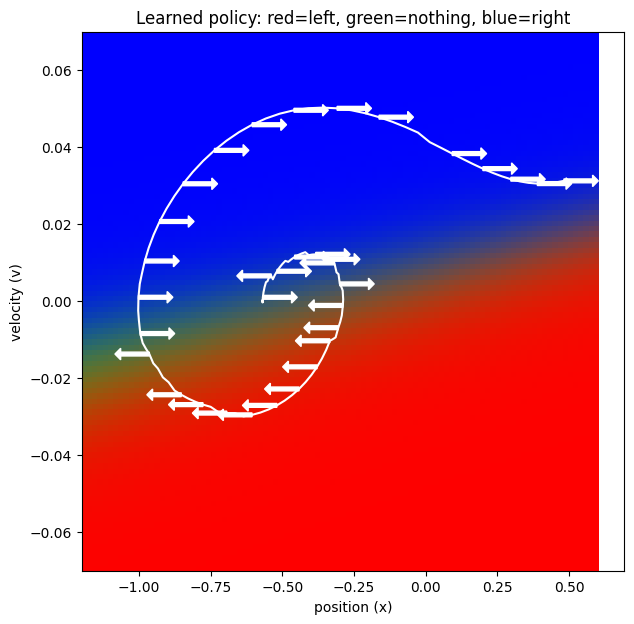

In [28]:
if final_mean > -150:
    with gym.make("MountainCar-v0").env as env_mc:
        visualize_mountain_car(env_mc, agent)

### Задание 2.2.

Будем запускать несколько эпизодов параллельно с помощью `joblib`, что ускорит обучение агента.

In [36]:
env = gym.make("MountainCar-v0").env
n_actions = env.action_space.n

agent = MLPClassifier(
        hidden_layer_sizes=(40, 40),
        activation="tanh",
    )

agent.partial_fit(
    [env.reset()[0]] * n_actions,
    range(n_actions),
    classes=range(n_actions),
)

n_sessions = 250
percentile = 70
log2 = []

In [37]:
from joblib import Parallel, delayed

n_jobs = 4

t0_jl = time.time()

for i in range(100):
    seeds = [i * n_sessions + j for j in range(n_sessions)]
    sessions = Parallel(n_jobs=n_jobs)(
        delayed(generate_session_standalone)(agent, seed)
        for seed in seeds
    )
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_arr = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_arr, percentile
    )

    if len(elite_states) == 0:
        print(f"{i}) skip")
        continue

    agent.partial_fit(elite_states, elite_actions)

    mean_reward = np.mean(rewards_arr)
    threshold = np.percentile(rewards_arr, percentile)
    log2.append([mean_reward, threshold])
    print(f"{i}) mean_reward={mean_reward:.1f}, threshold={threshold:.1f}")

    if mean_reward > -150:
        break

elapsed_jl = time.time() - t0_jl
print(f"Время без joblib: {elapsed:.1f} сек")
print(f"Время с joblib: {elapsed_jl:.1f} сек")

final_mean = log2[-1][0] if log2 else float("-inf")
print(f"\nСредняя награда: {final_mean:.1f}")

0) mean_reward=-9972.7, threshold=-10000.0
1) mean_reward=-9898.2, threshold=-10000.0
2) mean_reward=-9856.3, threshold=-10000.0
3) mean_reward=-9891.6, threshold=-10000.0
4) mean_reward=-9524.5, threshold=-10000.0
5) mean_reward=-9161.5, threshold=-10000.0
6) mean_reward=-8690.1, threshold=-10000.0
7) mean_reward=-8894.8, threshold=-10000.0
8) mean_reward=-7925.9, threshold=-6760.8
9) mean_reward=-7864.7, threshold=-6562.3
10) mean_reward=-6313.1, threshold=-4193.8
11) mean_reward=-5297.7, threshold=-3124.4
12) mean_reward=-3571.0, threshold=-2049.1
13) mean_reward=-3415.9, threshold=-1902.1
14) mean_reward=-2247.1, threshold=-1494.6
15) mean_reward=-1681.4, threshold=-1120.1
16) mean_reward=-1144.9, threshold=-810.2
17) mean_reward=-1038.3, threshold=-725.8
18) mean_reward=-762.4, threshold=-579.7
19) mean_reward=-613.0, threshold=-483.0
20) mean_reward=-472.8, threshold=-398.4
21) mean_reward=-387.3, threshold=-321.0
22) mean_reward=-361.8, threshold=-308.0
23) mean_reward=-338.9, t

Использование joblib чуть ускорило обучение агента:
* Время без joblib: 1320.2 сек
* Время с joblib: 1148.2 сек

Переиспользуем старые сэмплы 3-х последних итераций:

In [40]:
env = gym.make("MountainCar-v0").env
n_actions = env.action_space.n

agent = MLPClassifier(
        hidden_layer_sizes=(40, 40),
        activation="tanh",
    )

agent.partial_fit(
    [env.reset()[0]] * n_actions,
    range(n_actions),
    classes=range(n_actions),
)

n_sessions = 250
percentile = 70
log3 = []

In [41]:
from collections import deque

n_reuse = 3
history = deque(maxlen=n_reuse)

for i in range(100):
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]
    history.append(sessions)

    all_sessions = []
    for batch in history:
        all_sessions.extend(batch)

    states_batch, actions_batch, rewards_batch = zip(*all_sessions)
    rewards_arr = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_arr, percentile
    )

    if len(elite_states) == 0:
        print(f"{i}) skip")
        continue

    agent.partial_fit(elite_states, elite_actions)

    current_rewards = [s[2] for s in sessions]
    mean_reward = np.mean(current_rewards)
    threshold = np.percentile(rewards_arr, percentile)
    log3.append([mean_reward, threshold])
    print(f"{i}) mean_reward={mean_reward:.1f}, threshold={threshold:.1f}")

    if mean_reward > -150:
        break

final_mean = log3[-1][0] if log3 else float("-inf")
print(f"\nСредняя награда: {final_mean:.1f}")

0) mean_reward=-6648.0, threshold=-4330.0
1) mean_reward=-3543.2, threshold=-2867.0
2) mean_reward=-2355.4, threshold=-2229.6
3) mean_reward=-1937.3, threshold=-1672.7
4) mean_reward=-1663.8, threshold=-1413.7
5) mean_reward=-1388.5, threshold=-1196.8
6) mean_reward=-1224.2, threshold=-1082.1
7) mean_reward=-996.8, threshold=-933.7
8) mean_reward=-966.3, threshold=-835.7
9) mean_reward=-835.9, threshold=-732.4
10) mean_reward=-728.1, threshold=-675.4
11) mean_reward=-702.0, threshold=-607.7
12) mean_reward=-664.0, threshold=-571.7
13) mean_reward=-619.9, threshold=-544.0
14) mean_reward=-605.5, threshold=-523.7
15) mean_reward=-555.5, threshold=-494.0
16) mean_reward=-543.6, threshold=-472.0
17) mean_reward=-492.9, threshold=-441.0
18) mean_reward=-466.2, threshold=-416.7
19) mean_reward=-435.0, threshold=-393.7
20) mean_reward=-416.9, threshold=-371.7
21) mean_reward=-388.0, threshold=-351.0
22) mean_reward=-376.5, threshold=-331.7
23) mean_reward=-361.3, threshold=-321.0
24) mean_rew

Теперь попробуем добиться значение средней награды -100.

In [42]:
env = gym.make("MountainCar-v0").env
n_actions = env.action_space.n

agent = MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="tanh",
        warm_start=True,
        max_iter=1
    )

agent.partial_fit(
    [env.reset()[0]] * n_actions,
    range(n_actions),
    classes=range(n_actions),
)

n_sessions = 250
percentile = 50
log4 = []

In [43]:
n_reuse = 3

history = deque(maxlen=n_reuse)

for i in range(300):
    if i > 200:
        percentile = 20

    sessions = [generate_session(env, agent) for _ in range(n_sessions)]
    history.append(sessions)

    all_sessions = []
    for batch in history:
        all_sessions.extend(batch)

    states_batch, actions_batch, rewards_batch = zip(*all_sessions)
    rewards_arr = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_arr, percentile
    )

    if len(elite_states) == 0:
        print(f"{i}) skip")
        continue

    agent.partial_fit(elite_states, elite_actions)

    current_rewards = [s[2] for s in sessions]
    mean_reward = np.mean(current_rewards)
    threshold = np.percentile(rewards_arr, percentile)
    log4.append([mean_reward, threshold])
    print(f"{i}) mean_reward={mean_reward:.1f}, threshold={threshold:.1f}")

    if mean_reward > -100:
        break

final_mean = log4[-1][0] if log4 else float("-inf")
print(f"\nСредняя награда: {final_mean:.1f}")

0) mean_reward=-9385.2, threshold=-10000.0
1) mean_reward=-8111.8, threshold=-10000.0
2) mean_reward=-7562.4, threshold=-10000.0
3) mean_reward=-6964.8, threshold=-9517.5
4) mean_reward=-6112.0, threshold=-7302.0
5) mean_reward=-5534.9, threshold=-5931.5
6) mean_reward=-5269.1, threshold=-5140.0
7) mean_reward=-4725.5, threshold=-4593.5
8) mean_reward=-3103.8, threshold=-3634.5
9) mean_reward=-3634.9, threshold=-3217.5
10) mean_reward=-3112.2, threshold=-2842.0
11) mean_reward=-2773.4, threshold=-2690.0
12) mean_reward=-2305.4, threshold=-2367.5
13) mean_reward=-2147.3, threshold=-2055.5
14) mean_reward=-2056.0, threshold=-1866.5
15) mean_reward=-1701.9, threshold=-1685.5
16) mean_reward=-1520.9, threshold=-1548.5
17) mean_reward=-1288.6, threshold=-1378.0
18) mean_reward=-1297.2, threshold=-1243.0
19) mean_reward=-1188.1, threshold=-1149.5
20) mean_reward=-1052.1, threshold=-1077.0
21) mean_reward=-932.7, threshold=-969.5
22) mean_reward=-857.5, threshold=-880.5
23) mean_reward=-806.2

Средняя награда получилась близка к -100 (-102.4).

/home/users/.venv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.min_position to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.min_position` for environment variables or `env.get_wrapper_attr('min_position')` that will search the reminding wrappers.
  logger.warn(
/home/users/.venv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.max_position to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.max_position` for environment variables or `env.get_wrapper_attr('max_position')` that will search the reminding wrappers.
  logger.warn(
/home/users/.venv/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.max_speed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.max_speed` for environment v

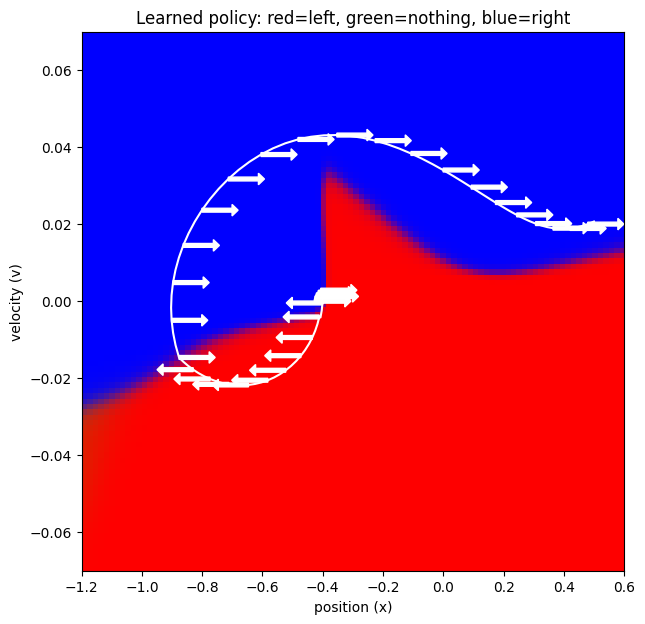

In [45]:
with gym.make("MountainCar-v0").env as env_mc:
    visualize_mountain_car(env_mc, agent)

Графики по предыдущим заданиям, связанным со средой MountainCar-v0:

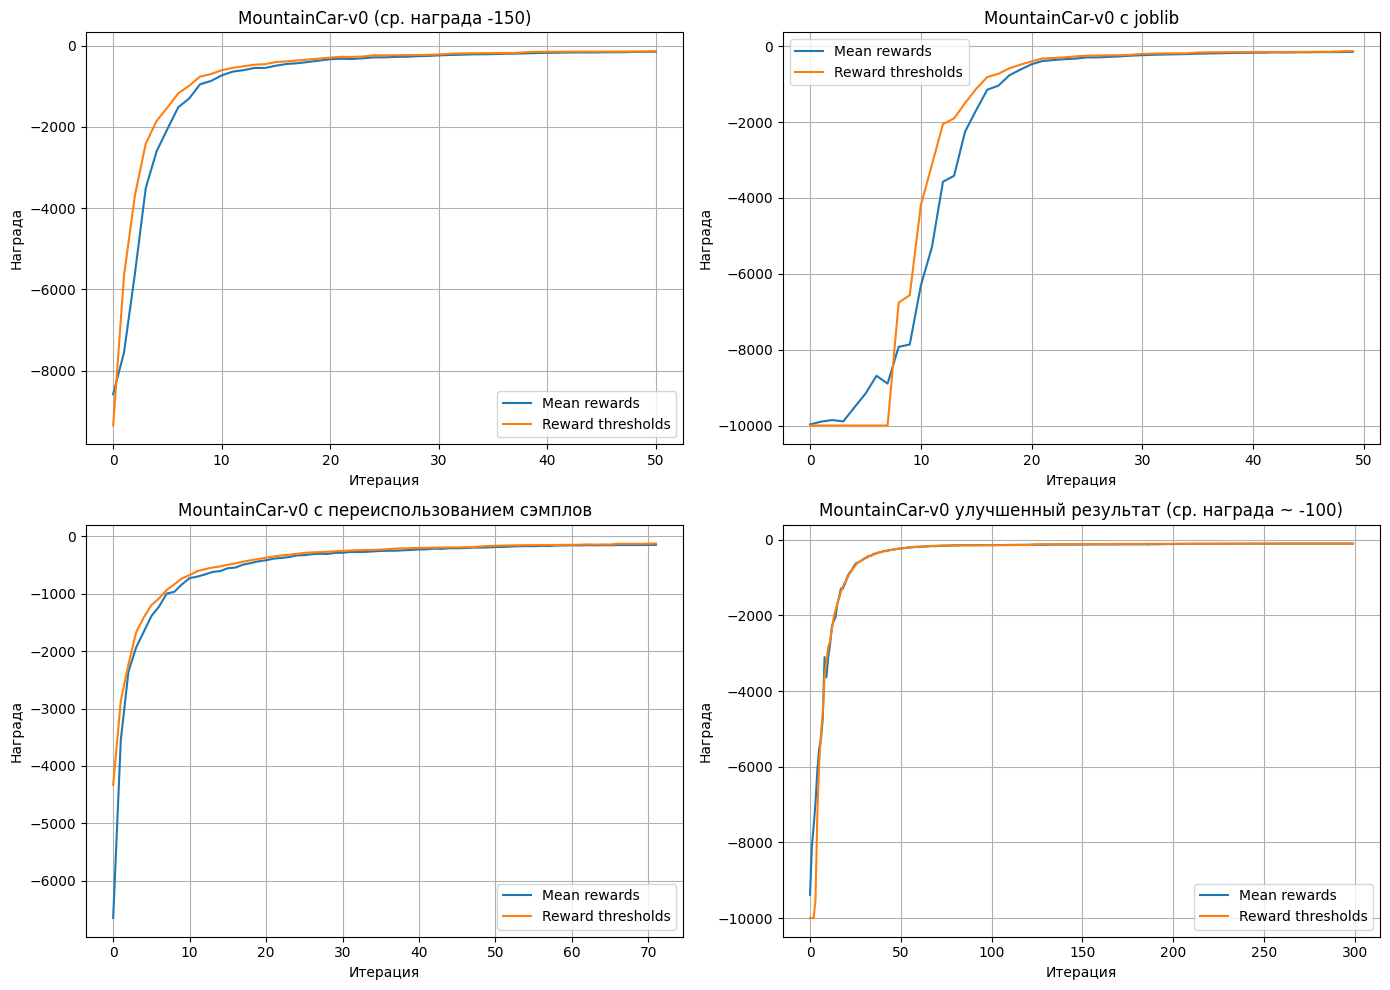

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titles = [
    "MountainCar-v0 (ср. награда -150)",
    "MountainCar-v0 с joblib",
    "MountainCar-v0 с переиспользованием сэмплов",
    "MountainCar-v0 улучшенный результат (ср. награда ~ -100)"
]

logs = [log1, log2, log3, log4]

axes = axes.flatten()

for ax, title, log_data in zip(axes, titles, logs):

    mean_rewards = [x[0] for x in log_data]
    thresholds = [x[1] for x in log_data]

    ax.plot(mean_rewards, label="Mean rewards")
    ax.plot(thresholds, label="Reward thresholds")

    ax.set_xlabel("Итерация")
    ax.set_ylabel("Награда")
    ax.set_title(title)

    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.

# Итог:
В данном ноутбуке рассмотрен метод кросс-энтропии (табличный и глубокий):

На примере среды Taxi-v3:

* 1.1) исследовано влияние гиперпараметров percentile и n_sessions на сходимость алгоритма. Построены графики, показывающие, как изменение этих параметров влияет на скорость обучения и стабильность,

* 1.2) подобраны оптимальные гиперпараметры, при которых алгоритм достигает стабильной положительной средней награды.

На примере среды MountainCar-v0:

* 2.1) увеличен параметр t_max и достигнута средняя награда -150,

* 2.2) реализованы следующие улучшения для ускорения обучения:
    * распараллеливание: использована библиотека joblib с созданием новых экземпляров среды в каждом воркере.
    * переиспользование сэмплов: при вычислении порога и обучении используются сэмплы с 3 предыдущих итераций.
    * достижение цели: благодаря улучшениям и настройке гиперпараметров достигнута средняя награда около -100.